In [1]:
!pip install Pillow

In [10]:
import os, random
from PIL import Image, ImageEnhance

classes = ['ae', 'ai', 'canva', 'figma', 'inkscape', 'lr', 'paint', 'photoshop', 'procreate', 'sketch']
base_dir = 'dataset/base_images'
output_dir = 'dataset_ready'
target_count = 100
target_size = (64, 64)

for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    if not os.path.isdir(cls_path):
        print(f"Папка {cls_path} не найдена, пропускаем.")
        continue
    
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if not images:
        print(f"В папке {cls_path} нет изображений!")
        continue
    
    out_cls = os.path.join(output_dir, cls)
    os.makedirs(out_cls, exist_ok=True)
    
    for i in range(target_count):
        src_name = random.choice(images)
        img = Image.open(os.path.join(cls_path, src_name)).convert('RGB')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        
        if i == 0:
            new_img = img
        else:
            angle = random.randint(-30, 30)
            img = img.rotate(angle, expand=False, fillcolor=(255,255,255))
            
            enh = ImageEnhance.Brightness(img)
            img = enh.enhance(random.uniform(0.7, 1.3))
            
            enh = ImageEnhance.Contrast(img)
            img = enh.enhance(random.uniform(0.7, 1.3))
            
            w, h = img.size
            shift_x = random.randint(-5, 5)
            shift_y = random.randint(-5, 5)
            img = img.transform(img.size, Image.AFFINE, (1,0,shift_x,0,1,shift_y), fillcolor=(255,255,255))
            new_img = img
        
        save_name = f"{cls}_{i:03d}.png"
        new_img.save(os.path.join(out_cls, save_name), 'PNG')
    
    print(f"{cls}: создано {target_count} изображений")

print("\n✅ Готово! Проверьте папку dataset_ready.")

ae: создано 100 изображений
ai: создано 100 изображений
canva: создано 100 изображений
figma: создано 100 изображений
inkscape: создано 100 изображений
lr: создано 100 изображений
paint: создано 100 изображений
photoshop: создано 100 изображений
procreate: создано 100 изображений
sketch: создано 100 изображений

✅ Готово! Проверьте папку dataset_ready.


In [11]:
import pandas as pd

data = []
for cls in classes:
    cls_dir = os.path.join('dataset_ready', cls)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            if fname.endswith('.png'):
                data.append({'filename': fname, 'class': cls})

df = pd.DataFrame(data)
df.to_csv('annotations.csv', index=False)
print(f"Файл annotations.csv создан. Записей: {len(df)}")
df.head()

Файл annotations.csv создан. Записей: 1000


,filename,class
0,ae_000.png,ae
1,ae_001.png,ae
2,ae_002.png,ae
3,ae_003.png,ae
4,ae_004.png,ae


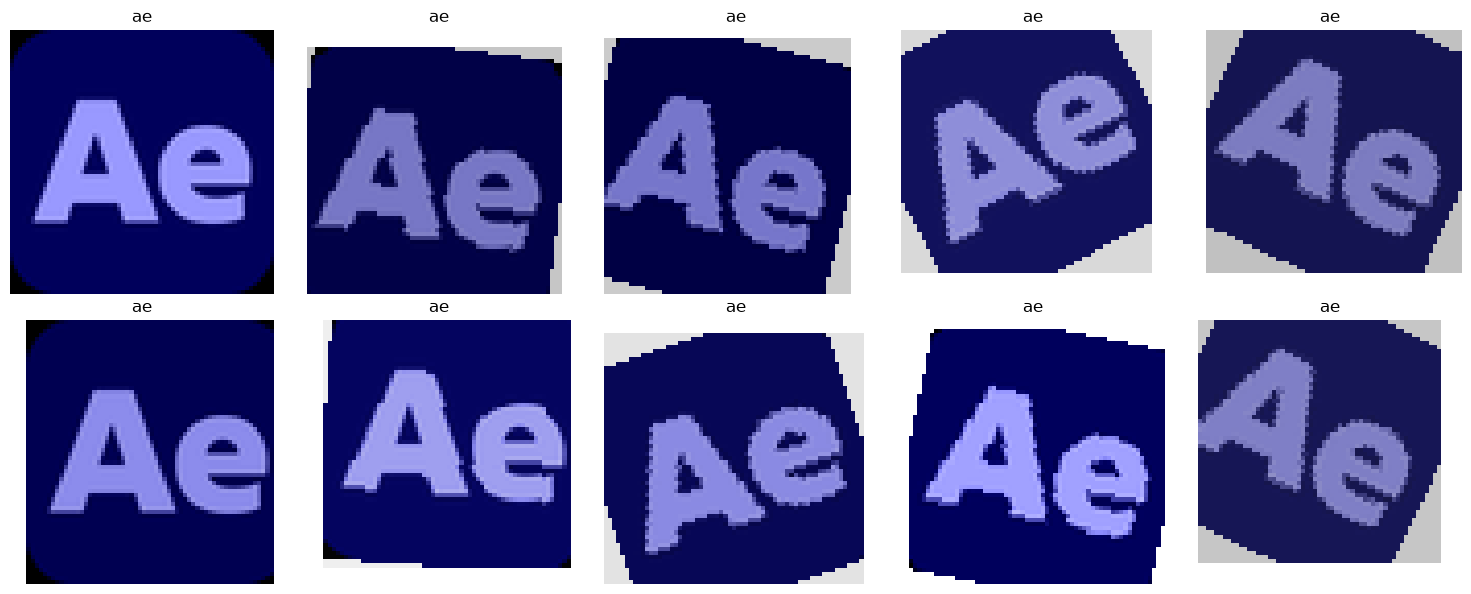

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(df):
        row = df.iloc[i]
        img_path = os.path.join('dataset_ready', row['class'], row['filename'])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(row['class'])
        ax.axis('off')
plt.tight_layout()
plt.show()

Объект датасета:Логотипы графических редакторов
Количество классов: 10
Количество объектов: в каждом классе 100
Общий объем датасета: 1000 изображений
Разрешение изображений:	64×64 пикселя
Формат файла изображения: png
Способ аннотации:Многоклассовая классификация
Формат файла аннотации:	CSV (annotations.csv)
Метод аугментации:Повороты, яркость, контраст, сдвиги

In [14]:
import os
print(os.getcwd())
print(os.path.abspath('annotations.csv'))

C:\Users\User
C:\Users\User\annotations.csv


In [15]:
!pip install kaggle


   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ------------- -------------------------- 1/3 [jupytext]
   -------------------------- ------------- 2/3 [kaggle]
   ---------------------------------------- 3/3 [kaggle]

